In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/home/kiran/Downloads/cleaned-data/Raw-Data/NMDatabase.csv")

In [3]:
data

,NME ID,Ref.No.,Name of Ship,Type of Ship,Date of Report,Delay (in days),Description of the incident and cause analysis,Location,Probability of Reoccurence,Cause Analysis,...,IndirectCause,RootCause,RevisedIncidentCategory,LessionLearnt,ReviewComments,ClosingNote,ClosingDate,Incident_Category_Potential,Probability_of_Reoccurence,Port Country Name
0,NME100000,CAL-01/2012,APL CALIFORNIA,CONTAINER,2012-01-03,0.0,On 03 Jan 2012 @ 0254 hrs vessel berthed at qi...,Galley,Likely,Suspect undeclared machinery stowed inside a c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
1,NME100001,CHI-01/2012,TS CHINA,CONTAINER,2012-01-05,0.0,"The ship departed port of osaka ,and main engi...",Machinery Room,Very Low,Failure to follow repair / maintenance instruc...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Critical-Severe,Very Unlikely-Very Low,NaN
2,NME100002,CHI-02/2012,TS CHINA,CONTAINER,2012-01-06,0.0,While the Ship was in Port ( NAGOYA - JAPAN ) ...,Machinery Room,Very Low,Failure to follow repair/maintenance instructi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Very Unlikely-Very Low,NaN
3,NME100003,FLD-01-2012,APL FLORIDA,CONTAINER,2012-01-09,2.0,"Vessel approaching berth at Yokohama,Japan wit...",Bridge,Very Low,"Prior arrival to Yokohama, vessel had very bad...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Unlikely-Very Low,NaN
4,NME100004,CAP-001/12,CALA PINGUINO,CONTAINER,2012-01-23,16.0,AFT TUG LINE PARTED WHILE DEPARTING PUERTO CAB...,Mooring Area,Very Likely,Duty Officer should always check the quality o...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Likely-Very High,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12441,NME112441,NM/NBAL/2020/Apr/4,NORD BALTIC,NAN,2020-04-12 17:43:37.050,NaN,Stevedores about to transfer shore escavator u...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,Thank you for being vigilant and devoting time...,2020-04-29 00:00:00,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
12442,NME112442,NM/NSFX/2020/Apr/6,NAVIOS FELIX,NAN,2020-04-21 06:22:51.907,NaN,"During Safety around checked, 4/E was focussin...",Sea,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Catastrophic-Major-Extreme,Unlikely-Low-Marginal,NaN
12443,NME112443,NM/VOLN/2020/Apr/7,VOLANTE,NAN,2020-04-30 12:20:24.683,NaN,During routine round of the engine room it was...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Likely-High-Medium-Moderate,NaN
12444,NME112444,NM/HOUM/2020/Apr/8,HOURAI MARU,NAN,2020-04-24 13:43:40.970,NaN,While casting off the tug at aft station the t...,Port,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,UNSAFE CONDITION.NM Closed,2020-05-11 00:00:00,Minor-Low-Slight,Unlikely-Low-Marginal,NaN


In [4]:
data.columns

Index(['NME ID', 'Ref.No.', 'Name of Ship', 'Type of Ship', 'Date of Report',
       'Delay (in days)', 'Description of the incident and cause analysis',
       'Location', 'Probability of Reoccurence', 'Cause Analysis',
       'Counter measure to prevent recurrence',
       'Suggested Corrective Action (Office Use)',
       'Date Corrective action completed', 'Area of Concern',
       'Date Investigation Commenced', 'Target Date',
       'Date of Investigation Completion', 'Extension (if any) with remarks',
       'Time Period (in days)', 'Status', 'Master', 'Chief Engineer',
       'Superintendent', 'Details of potential loss Category',
       'Date of Near Miss', 'PIC', 'Port Name', 'Related Department',
       'Description of event leading to the incident',
       'Immediate action taken', 'Potential extent of damage/injury',
       'Potential Damage category', 'Potential Damage subcategory',
       'Immediate action initiated', 'Learning Potential',
       'Severity of incident', 

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12446 entries, 0 to 12445
Data columns (total 57 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   NME ID                                          12446 non-null  str    
 1   Ref.No.                                         12445 non-null  str    
 2   Name of Ship                                    12446 non-null  str    
 3   Type of Ship                                    12446 non-null  str    
 4   Date of Report                                  11787 non-null  str    
 5   Delay (in days)                                 1251 non-null   float64
 6   Description of the incident and cause analysis  12344 non-null  str    
 7   Location                                        11773 non-null  str    
 8   Probability of Reoccurence                      11583 non-null  str    
 9   Cause Analysis                                  49

In [6]:
data['Area of Concern'].isnull().sum()

np.int64(3058)

In [7]:
data['Area of Concern'].value_counts()

Area of Concern
Safety Management                4112
Engine & Steering Compartment    1216
Mooring                          1052
Cargo And Ballast System          802
Navigation                        523
General App & Condition           484
Others                            453
Cowsp                             212
Crew Management                   172
Environment                       129
Company Documents                  87
Communication                      75
Planned Maintenance                25
Monitoring                         23
Execution & Monitoring             13
Lack Of Procedure                   6
Annexure 1 To Annexure 6            4
Name: count, dtype: int64

In [8]:
data['Cause Analysis'].isna().sum() 

np.int64(7510)

In [9]:
data['Chief Engineer'].value_counts()

Chief Engineer
C/E.SelvaKumar                 46
PRS Nair                       31
Molano Alan                    26
Jiby Joseph                    24
Thirunavkkarasu chezhain       24
                               ..
Ruhul rai                       1
Rahul                           1
Mr James Martin                 1
Gulshan Singh Ramkala Singh     1
Felix B. Climaco                1
Name: count, Length: 300, dtype: int64

In [10]:
data['Chief Engineer'].isna().sum()

np.int64(11406)

In [11]:
data['ClosingDate'].isna().sum()

np.int64(7084)

In [12]:
data['ClosingNote'].isna().sum()

np.int64(6513)

In [13]:
data['Closure Date - CA'].isna().sum()

np.int64(12191)

In [14]:
data.drop(columns=['Closure Date - CA'], inplace=True)

In [15]:
data['Corrective Action'].isna().sum()

np.int64(9634)

In [16]:
data.drop(columns=['Corrective Action'], inplace=True)

In [17]:
data.columns

Index(['NME ID', 'Ref.No.', 'Name of Ship', 'Type of Ship', 'Date of Report',
       'Delay (in days)', 'Description of the incident and cause analysis',
       'Location', 'Probability of Reoccurence', 'Cause Analysis',
       'Counter measure to prevent recurrence',
       'Suggested Corrective Action (Office Use)',
       'Date Corrective action completed', 'Area of Concern',
       'Date Investigation Commenced', 'Target Date',
       'Date of Investigation Completion', 'Extension (if any) with remarks',
       'Time Period (in days)', 'Status', 'Master', 'Chief Engineer',
       'Superintendent', 'Details of potential loss Category',
       'Date of Near Miss', 'PIC', 'Port Name', 'Related Department',
       'Description of event leading to the incident',
       'Immediate action taken', 'Potential extent of damage/injury',
       'Potential Damage category', 'Potential Damage subcategory',
       'Immediate action initiated', 'Learning Potential',
       'Severity of incident', 

In [18]:
data['Counter measure to prevent recurrence'].value_counts()


Counter measure to prevent recurrence
1. The above mentioned near miss report was discussed with all the crew. The causes that lead to such a near miss were clearly explained.    2
The above scenario was discussed with all the crew member. Everyone understood the importance of wearing the PPE/Safety gears.               2
Proper recording of data should be carefully studied before entries are to be made into the appropriate record book                          2
Wind conditions shall be considered  during flag hoisting, if required additional person shall be used for hoisting.                         2
WINDLASS HYDRAULIC MOTOR TO BE OVERHAULED AND SAME ADDED IN DRY DOCK SPECS.                                                                  2
                                                                                                                                            ..
Proper PPE to be worn at all times when working on deck.                                                

In [19]:
data['Date Corrective action completed'].isna().sum()

np.int64(11381)

In [20]:
data['Date Investigation Commenced'].isna().sum()

np.int64(11463)

In [21]:
data['Date of Near Miss'].isna().sum()

np.int64(2)

In [22]:
data['Date of Report'].head(10)

0    2012-01-03
1    2012-01-05
2    2012-01-06
3    2012-01-09
4    2012-01-23
5    2012-01-09
6    2012-01-09
7    2012-01-13
8    2012-01-11
9    2012-01-14
Name: Date of Report, dtype: str

In [23]:
data['Delay (in days)'].isna().sum()

np.int64(11195)

In [24]:
data['Description of event leading to the incident'].isna().sum()   

np.int64(4827)

In [25]:
data['Details of potential loss Category'].head(20)

0     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
1     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
2     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
3     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
4     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
5     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
6     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
7     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
8     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
9     P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
10    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
11    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
12    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
13    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
14    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
15    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
16    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,(,C,...
17    P,O,S,S,I,B,L,E, ,C,O,N,S,E,Q,U,E,N,C,E, ,

In [26]:
data['Details of potential loss Category'].isna().sum() 

np.int64(7630)

In [27]:
data['Details of potential loss Category'].value_counts()

Details of potential loss Category
Personal Injury                                                                                                                                                                                                                                                363
Man Hour Lost ,Personal Injury                                                                                                                                                                                                                                 164
2) Personal Injury                                                                                                                                                                                                                                             152
Man Hour Lost                                                                                                                                                                               

In [28]:
data['DirectCause'].head(20)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: DirectCause, dtype: str

In [29]:
data['Due Date'].isna().sum()

np.int64(12189)

In [30]:
data['Extension (if any) with remarks'].isna().sum()

np.int64(12402)

In [31]:
data['External authority reporting required'].isna().sum()  

np.int64(9126)

In [32]:
data['Further Investigation Required'].isna().sum() 

np.int64(9126)

In [33]:
data['Immediate action initiated'].isna().sum()

np.int64(9417)

In [34]:
data['Incident communicated to oil majors'].isna().sum()

np.int64(9126)

In [35]:
data['Incident_Category_Potential'].head(20)    

0     Marginal-Moderate-Medium
1              Critical-Severe
2     Marginal-Moderate-Medium
3             Minor-Low-Slight
4             Minor-Low-Slight
5     Marginal-Moderate-Medium
6             Minor-Low-Slight
7              Critical-Severe
8     Marginal-Moderate-Medium
9             Minor-Low-Slight
10    Marginal-Moderate-Medium
11    Marginal-Moderate-Medium
12    Marginal-Moderate-Medium
13    Marginal-Moderate-Medium
14    Marginal-Moderate-Medium
15    Marginal-Moderate-Medium
16            Minor-Low-Slight
17    Marginal-Moderate-Medium
18            Minor-Low-Slight
19    Marginal-Moderate-Medium
Name: Incident_Category_Potential, dtype: str

In [36]:
data['Learning Potential']

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
          ...  
12441       Low
12442       NaN
12443       NaN
12444    Medium
12445    Medium
Name: Learning Potential, Length: 12446, dtype: str

In [37]:
data['Learning Potential'].isna().sum()

np.int64(4907)

In [38]:
data['Learning Potential'].value_counts()   

Learning Potential
Low       5488
Medium    1941
High       110
Name: count, dtype: int64

In [39]:
data['IndirectCause'].isna().sum()  

np.int64(12360)

In [40]:
data['Suggested Corrective Action (Office Use)'].value_counts()

Suggested Corrective Action (Office Use)
NIL                                                                                                                                                                                                                                                                                                                                                 318
Review pending                                                                                                                                                                                                                                                                                                                                       59
Review Pending                                                                                                                                                                                                                                                                 

In [41]:
data['LessionLearnt'].isna().sum()  

np.int64(10755)

In [42]:
data['Location'].value_counts()

Location
Sea               6884
Port              3024
On Deck            791
Machinery Room     383
Mooring Area       165
Bridge             164
Accommodation      136
Others              65
Galley              56
Cargo Hold          48
Ballast Tank        34
Pump Room           17
Engine Room          6
Name: count, dtype: int64

In [43]:
data['Master'].value_counts()

Master
Capt.AYYAGARI \nRAVISHANKAR    46
Rajasekar                      28
Pollentes Luis Rey             24
Senthil kumar                  24
Praveen Jaiswal                16
                               ..
Capt. Raj Srivastava            1
Capt. F Moraes                  1
Musharraf Iqbal                 1
Baljeet                         1
Jeremias L. Laranjo             1
Name: count, Length: 343, dtype: int64

In [44]:
data['NME ID'].value_counts()

NME ID
NME100000    1
NME100001    1
NME100002    1
NME100003    1
NME100004    1
            ..
NME112441    1
NME112442    1
NME112443    1
NME112444    1
NME112445    1
Name: count, Length: 12446, dtype: int64

In [45]:
data['Name of Ship'].value_counts() 

Name of Ship
KM HAKATA          213
FUJI GAS           196
TIRUMALA GAS       173
SABARIMALA GAS     169
NANYANG STAR       152
                  ... 
VIETNAM EXPRESS      1
LOWLANDS DAWN        1
LOWLANDS FUTURE      1
VIALLI               1
MENTOR               1
Name: count, Length: 357, dtype: int64

In [46]:
data['PIC'].value_counts()

PIC
Master                   115
Chief Officer             70
Chief Engineer            39
Ravi kumar.K              10
Second Engineer            5
Sachin Bagga               3
Satheesh Chinnadurai       3
Daniel C                   3
Arputharaj                 2
Naveen Kumar               1
Duraisamy Natarajan        1
Abhishek Kumar             1
Electricalofficer          1
Khalid Nawaz               1
Second Officer             1
Harris Surendar Moses      1
Name: count, dtype: int64

In [47]:
data['Port Country Name'].isna().sum()  

np.int64(12032)

In [48]:
data['Port Name'].value_counts()

Port Name
SINGAPORE                           143
FUJAIRAH                             75
HOUSTON                              53
MUMBAI                               46
ROTTERDAM                            42
                                   ... 
DONGGUAN                              1
HODEIDAH                              1
AUGHINISH ISLAND MARINE TERMINAL      1
ODENSE                                1
WADI FEIRAN                           1
Name: count, Length: 671, dtype: int64

In [49]:
data['Potential Damage category'].isna().sum()

np.int64(9126)

In [50]:
data['Potential Damage subcategory'].isna().sum()   

np.int64(9126)

In [51]:
data['Potential extent of damage/injury'].isna().sum()  

np.int64(5063)

In [52]:
data['Potential extent of damage/injury'].value_counts()

Potential extent of damage/injury
NIL                                                                                                                              115
Nil                                                                                                                               94
NONE                                                                                                                              93
Personal Injury                                                                                                                   72
none                                                                                                                              52
                                                                                                                                ... 
Caused injury to his foot seriously                                                                                                1
Loss of steering may lead to collis

In [53]:
data['Potential incident to be shared with industry'].isna().sum()

np.int64(9126)

In [54]:
data['Probability of Reoccurence'].isna().sum()

np.int64(863)

In [55]:
data['Probability of Reoccurence'].value_counts()


Probability of Reoccurence
Unlikely                                                                                        4279
Likely                                                                                          3927
Very Unlikely                                                                                   1463
Very Likely                                                                                      866
Low                                                                                              297
3) Unlikely                                                                                      260
2) Likely                                                                                        214
1) Very Unlikely                                                                                 117
Medium                                                                                            47
Very Low                                                        

In [56]:
data['Probability_of_Reoccurence'].value_counts()

Probability_of_Reoccurence
Unlikely-Low-Marginal          4578
Likely-High-Medium-Moderate    4002
Very Unlikely-Very Low         1503
Others                         1496
Very Likely-Very High           867
Name: count, dtype: int64

In [57]:
data['Ref.No.'].value_counts()

Ref.No.
CAL-01/2012           1
CHI-01/2012           1
CHI-02/2012           1
FLD-01-2012           1
CAP-001/12            1
                     ..
NM/NBAL/2020/Apr/4    1
NM/NSFX/2020/Apr/6    1
NM/VOLN/2020/Apr/7    1
NM/HOUM/2020/Apr/8    1
NM/LORD/2020/May/3    1
Name: count, Length: 12445, dtype: int64

In [58]:
data['Related Department'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Related Department, dtype: str

In [59]:
data['Related Department'].isna().sum() 

np.int64(8518)

In [60]:
data['Remarks - CA']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12441    NaN
12442    NaN
12443    NaN
12444    NaN
12445    NaN
Name: Remarks - CA, Length: 12446, dtype: str

In [61]:
data['Remarks - CA'].isna().sum()   

np.int64(12190)

In [62]:
data['Report Type'].isna().sum()    

np.int64(11838)

In [63]:
data['Related Department'].isna().sum()

np.int64(8518)

In [64]:
data['ReviewComments'].isna().sum() 

np.int64(10918)

In [65]:
data['RevisedIncidentCategory']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12441    NaN
12442    NaN
12443    NaN
12444    NaN
12445    NaN
Name: RevisedIncidentCategory, Length: 12446, dtype: str

In [66]:
data['RevisedIncidentCategory'].isna().sum()    

np.int64(12184)

In [67]:
data['RootCause'].isna().sum()  

np.int64(12341)

In [68]:
data['Severity of incident'].isna().sum()

np.int64(4130)

In [69]:
data['Severity of incident'].value_counts()

Severity of incident
Low       4759
Medium    2455
High      1102
Name: count, dtype: int64

In [70]:
data['Status'].value_counts()

Status
Closed          9766
Open             943
Invalid          634
Under Review     452
Name: count, dtype: int64

In [71]:
data['Status of CA'].isna().sum()   

np.int64(12189)

In [72]:
data['Superintendent'].isna().sum() 

np.int64(11272)

In [73]:
data['Target Date'].isna().sum()    

np.int64(11224)

In [74]:
data['Time Period (in days)'].value_counts()    

Time Period (in days)
 2.0        15
 1.0        15
 4.0         9
 52.0        8
 3.0         7
            ..
-41655.0     1
-41698.0     1
-41669.0     1
-41651.0     1
-41687.0     1
Name: count, Length: 149, dtype: int64

In [75]:
data['Time Period (in days)'].isna().sum()

np.int64(12108)

In [76]:
data['Type of Ship'].isna().sum()   

np.int64(0)

In [77]:
data

,NME ID,Ref.No.,Name of Ship,Type of Ship,Date of Report,Delay (in days),Description of the incident and cause analysis,Location,Probability of Reoccurence,Cause Analysis,...,IndirectCause,RootCause,RevisedIncidentCategory,LessionLearnt,ReviewComments,ClosingNote,ClosingDate,Incident_Category_Potential,Probability_of_Reoccurence,Port Country Name
0,NME100000,CAL-01/2012,APL CALIFORNIA,CONTAINER,2012-01-03,0.0,On 03 Jan 2012 @ 0254 hrs vessel berthed at qi...,Galley,Likely,Suspect undeclared machinery stowed inside a c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
1,NME100001,CHI-01/2012,TS CHINA,CONTAINER,2012-01-05,0.0,"The ship departed port of osaka ,and main engi...",Machinery Room,Very Low,Failure to follow repair / maintenance instruc...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Critical-Severe,Very Unlikely-Very Low,NaN
2,NME100002,CHI-02/2012,TS CHINA,CONTAINER,2012-01-06,0.0,While the Ship was in Port ( NAGOYA - JAPAN ) ...,Machinery Room,Very Low,Failure to follow repair/maintenance instructi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Very Unlikely-Very Low,NaN
3,NME100003,FLD-01-2012,APL FLORIDA,CONTAINER,2012-01-09,2.0,"Vessel approaching berth at Yokohama,Japan wit...",Bridge,Very Low,"Prior arrival to Yokohama, vessel had very bad...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Unlikely-Very Low,NaN
4,NME100004,CAP-001/12,CALA PINGUINO,CONTAINER,2012-01-23,16.0,AFT TUG LINE PARTED WHILE DEPARTING PUERTO CAB...,Mooring Area,Very Likely,Duty Officer should always check the quality o...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Likely-Very High,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12441,NME112441,NM/NBAL/2020/Apr/4,NORD BALTIC,NAN,2020-04-12 17:43:37.050,NaN,Stevedores about to transfer shore escavator u...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,Thank you for being vigilant and devoting time...,2020-04-29 00:00:00,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
12442,NME112442,NM/NSFX/2020/Apr/6,NAVIOS FELIX,NAN,2020-04-21 06:22:51.907,NaN,"During Safety around checked, 4/E was focussin...",Sea,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Catastrophic-Major-Extreme,Unlikely-Low-Marginal,NaN
12443,NME112443,NM/VOLN/2020/Apr/7,VOLANTE,NAN,2020-04-30 12:20:24.683,NaN,During routine round of the engine room it was...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Likely-High-Medium-Moderate,NaN
12444,NME112444,NM/HOUM/2020/Apr/8,HOURAI MARU,NAN,2020-04-24 13:43:40.970,NaN,While casting off the tug at aft station the t...,Port,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,UNSAFE CONDITION.NM Closed,2020-05-11 00:00:00,Minor-Low-Slight,Unlikely-Low-Marginal,NaN


In [78]:
data.shape
data.columns
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12446 entries, 0 to 12445
Data columns (total 55 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   NME ID                                          12446 non-null  str    
 1   Ref.No.                                         12445 non-null  str    
 2   Name of Ship                                    12446 non-null  str    
 3   Type of Ship                                    12446 non-null  str    
 4   Date of Report                                  11787 non-null  str    
 5   Delay (in days)                                 1251 non-null   float64
 6   Description of the incident and cause analysis  12344 non-null  str    
 7   Location                                        11773 non-null  str    
 8   Probability of Reoccurence                      11583 non-null  str    
 9   Cause Analysis                                  49

,Delay (in days),Time Period (in days)
count,1251.000000,338.000000
mean,4.031175,-6237.183432
std,1662.269228,14931.322805
min,-41501.000000,-41698.000000
25%,0.000000,2.000000
50%,1.000000,21.000000
75%,3.000000,57.250000
max,41610.000000,195.000000


In [79]:
date_cols = [
    'Date of Report', 'Date Corrective action completed',
    'Date Investigation Commenced', 'Target Date',
    'Date of Investigation Completion', 'Date of Near Miss',
    'ClosingDate'
]

for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

/tmp/ipykernel_5720/967419297.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], errors='coerce')


In [80]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.head(20)

,Missing Count,Missing %
Extension (if any) with remarks,12402,99.646473
IndirectCause,12360,99.309015
RootCause,12341,99.156355
Remarks - CA,12190,97.943114
PIC,12189,97.935080
Status of CA,12189,97.935080
Due Date,12189,97.935080
RevisedIncidentCategory,12184,97.894906
Time Period (in days),12108,97.284268
Port Country Name,12032,96.673630


In [81]:
drop_cols = [
    'Extension (if any) with remarks',
    'IndirectCause',
    'RootCause',
    'Remarks - CA',
    'PIC',
    'Status of CA',
    'Due Date',
    'RevisedIncidentCategory',
    'Time Period (in days)',
    'Port Country Name',
    'Report Type',
    'Date Investigation Commenced',
    'Chief Engineer',
    'Date Corrective action completed',
    'Date of Investigation Completion',
    'Master',
    'Superintendent',
    'Target Date'
]

data = data.drop(columns=drop_cols)

In [82]:
data = data.dropna(subset=['Delay (in days)'])

In [83]:
data['Type of Ship'].value_counts().head(10)

Type of Ship
TANKER          474
CONTAINER       310
BULK CARRIER    297
OIL TANKER      146
LPG CARRIER      22
NAN               2
Name: count, dtype: int64

In [84]:
data['Type of Ship'].value_counts().head(10)

Type of Ship
TANKER          474
CONTAINER       310
BULK CARRIER    297
OIL TANKER      146
LPG CARRIER      22
NAN               2
Name: count, dtype: int64

In [85]:
data['Delay (in days)'].describe()

count     1251.000000
mean         4.031175
std       1662.269228
min     -41501.000000
25%          0.000000
50%          1.000000
75%          3.000000
max      41610.000000
Name: Delay (in days), dtype: float64

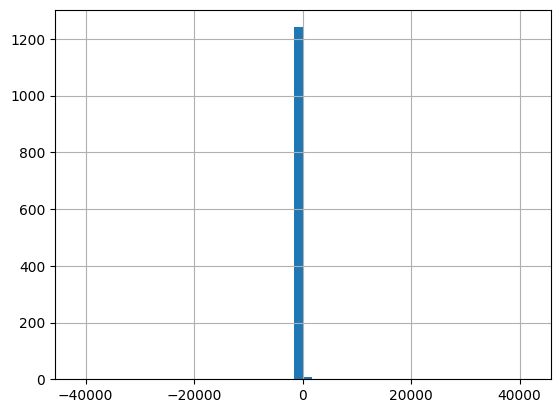

In [86]:
import matplotlib.pyplot as plt

data['Delay (in days)'].hist(bins=50)
plt.show()

In [87]:
data = data[
    (data['Delay (in days)'] >= 0) &
    (data['Delay (in days)'] <= 30)
]

In [88]:
Q1 = data['Delay (in days)'].quantile(0.25)
Q3 = data['Delay (in days)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[
    (data['Delay (in days)'] >= lower) &
    (data['Delay (in days)'] <= upper)
]

In [89]:
data['Delay (in days)'].describe()

count    1040.000000
mean        0.808654
std         1.245172
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: Delay (in days), dtype: float64

In [90]:
data['Delay (in days)'].value_counts().head(10)

Delay (in days)
0.0    599
1.0    247
2.0     82
4.0     44
3.0     43
5.0     25
Name: count, dtype: int64

In [91]:
data[['Severity of incident', 'Delay (in days)']].head()

,Severity of incident,Delay (in days)
0,NaN,0.0
1,NaN,0.0
2,NaN,0.0
3,NaN,2.0
5,NaN,1.0


In [92]:
data[['Severity of incident', 'Delay (in days)']].isnull().sum()

Severity of incident    1040
Delay (in days)            0
dtype: int64

In [93]:
clean_box = data.dropna(subset=['Severity of incident', 'Delay (in days)'])

In [94]:
clean_box = clean_box[
    (clean_box['Delay (in days)'] >= 0) &
    (clean_box['Delay (in days)'] <= 30)
]

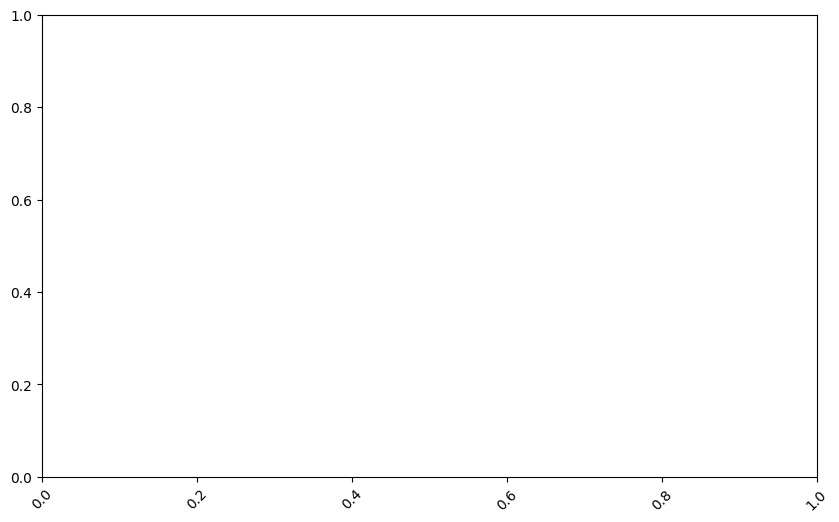

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Severity of incident', y='Delay (in days)', data=clean_box)
plt.xticks(rotation=45)
plt.show()

In [96]:
clean_box.shape
clean_box['Severity of incident'].value_counts()

Series([], Name: count, dtype: int64)

In [97]:
clean_box['Severity of incident'] = clean_box['Severity of incident'].astype(str)

In [98]:
clean_box['Severity of incident'].value_counts()

Series([], Name: count, dtype: int64)

In [99]:
delay_df = data[data['Delay (in days)'].notna()]

In [100]:
delay_df = delay_df[
    (delay_df['Delay (in days)'] >= 0) &
    (delay_df['Delay (in days)'] <= 100)
]

In [101]:
delay_df.shape

(1040, 37)

In [102]:
delay_df['Severity of incident'].value_counts()

Series([], Name: count, dtype: int64)

In [103]:
delay_df['Delay (in days)'].describe()

count    1040.000000
mean        0.808654
std         1.245172
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: Delay (in days), dtype: float64

In [104]:
data['Severity of incident'].value_counts()

Series([], Name: count, dtype: int64)

In [105]:
combined = data.dropna(subset=['Delay (in days)', 'Severity of incident'])
combined.shape

(0, 37)

In [106]:
data = data.loc[:, data.isnull().mean() < 0.7]

In [107]:
data.columns.tolist()


['NME ID',
 'Ref.No.',
 'Name of Ship',
 'Type of Ship',
 'Date of Report',
 'Delay (in days)',
 'Description of the incident and cause analysis',
 'Location',
 'Probability of Reoccurence',
 'Cause Analysis',
 'Counter measure to prevent recurrence',
 'Suggested Corrective Action (Office Use)',
 'Area of Concern',
 'Status',
 'Details of potential loss Category',
 'Date of Near Miss',
 'Incident_Category_Potential',
 'Probability_of_Reoccurence']

In [108]:
[['Delay', 'Time Period']]

[['Delay', 'Time Period']]

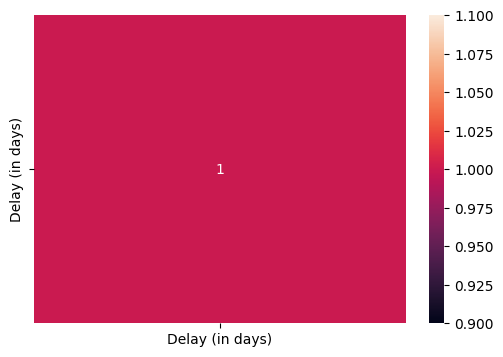

In [109]:
num_df = data.select_dtypes(include=['float64', 'int64'])

num_df = num_df.dropna()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(num_df.corr(), annot=True)
plt.show()

In [110]:
data.columns

Index(['NME ID', 'Ref.No.', 'Name of Ship', 'Type of Ship', 'Date of Report',
       'Delay (in days)', 'Description of the incident and cause analysis',
       'Location', 'Probability of Reoccurence', 'Cause Analysis',
       'Counter measure to prevent recurrence',
       'Suggested Corrective Action (Office Use)', 'Area of Concern', 'Status',
       'Details of potential loss Category', 'Date of Near Miss',
       'Incident_Category_Potential', 'Probability_of_Reoccurence'],
      dtype='str')

In [111]:
data.columns = data.columns.str.strip()  # remove spaces

data = data.rename(columns={
    'Ref.No.': 'ref_no',
    'Name of Ship': 'ship_name',
    'Type of Ship': 'ship_type',
    'Date of Report': 'report_date',
    'Delay (in days)': 'delay_days',
    'Description of the incident and cause analysis': 'description',
    'Probability of Reoccurence': 'probability',
    'Probability_of_Reoccurence': 'probability_dup',
    'Cause Analysis': 'cause_analysis',
    'Counter measure to prevent recurrence': 'counter_measure',
    'Suggested Corrective Action (Office Use)': 'corrective_action',
    'Area of Concern': 'area',
    'Details of potential loss Category': 'loss_category',
    'Date of Near Miss': 'near_miss_date',
    'Incident_Category_Potential': 'incident_category'
})

In [112]:
data.columns

Index(['NME ID', 'ref_no', 'ship_name', 'ship_type', 'report_date',
       'delay_days', 'description', 'Location', 'probability',
       'cause_analysis', 'counter_measure', 'corrective_action', 'area',
       'Status', 'loss_category', 'near_miss_date', 'incident_category',
       'probability_dup'],
      dtype='str')

In [113]:
(data['probability'] == data['probability_dup']).sum()

np.int64(0)

In [114]:
data.info()
data.isnull().sum()

<class 'pandas.DataFrame'>
Index: 1040 entries, 0 to 1296
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   NME ID             1040 non-null   str           
 1   ref_no             1039 non-null   str           
 2   ship_name          1040 non-null   str           
 3   ship_type          1040 non-null   str           
 4   report_date        1039 non-null   datetime64[us]
 5   delay_days         1040 non-null   float64       
 6   description        1030 non-null   str           
 7   Location           1017 non-null   str           
 8   probability        865 non-null    str           
 9   cause_analysis     1026 non-null   str           
 10  counter_measure    1027 non-null   str           
 11  corrective_action  1039 non-null   str           
 12  area               658 non-null    str           
 13  Status             1039 non-null   str           
 14  loss_category      1040 

NME ID                 0
ref_no                 1
ship_name              0
ship_type              0
report_date            1
delay_days             0
description           10
Location              23
probability          175
cause_analysis        14
counter_measure       13
corrective_action      1
area                 382
Status                 1
loss_category          0
near_miss_date         1
incident_category      0
probability_dup        0
dtype: int64

In [115]:
data = data.rename(columns={
    'Location': 'location',
    'Status': 'status'
})

In [116]:
data['area'] = data['area'].fillna('Unknown')

In [117]:
data['location'] = data['location'].fillna('Unknown')
data['description'] = data['description'].fillna('No description')

In [118]:
data['report_year'] = data['report_date'].dt.year
data['report_month'] = data['report_date'].dt.month

data['near_miss_year'] = data['near_miss_date'].dt.year
data['near_miss_month'] = data['near_miss_date'].dt.month

In [119]:
data['probability'].value_counts()

probability
Unlikely                             258
Low                                  253
Likely                               158
Very Unlikely                         74
Very Low                              32
Medium                                32
Very Likely                           30
High                                  13
Moderate                               9
Marginal                               2
Very High                              1
Commercial Loss / Reputation Loss      1
Minor                                  1
Critical / Severe Harm                 1
Name: count, dtype: int64

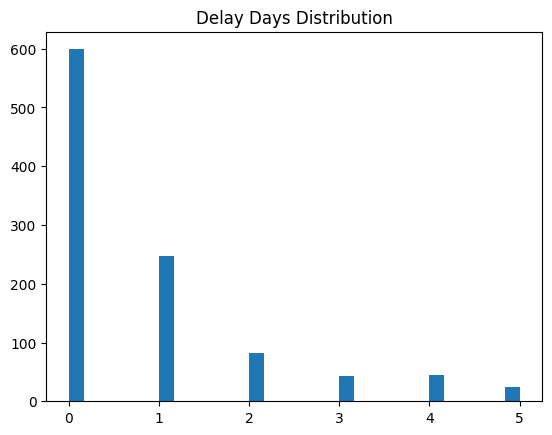

In [120]:
import matplotlib.pyplot as plt

plt.hist(data['delay_days'], bins=30)
plt.title("Delay Days Distribution")
plt.show()

In [121]:
data[data['delay_days'] < 0]

,NME ID,ref_no,ship_name,ship_type,report_date,delay_days,description,location,probability,cause_analysis,...,area,status,loss_category,near_miss_date,incident_category,probability_dup,report_year,report_month,near_miss_year,near_miss_month


In [122]:
data = data[data['delay_days'] >= 0]

In [123]:
data['report_year'].value_counts().sort_index()

report_year
2012.0    418
2013.0    621
Name: count, dtype: int64

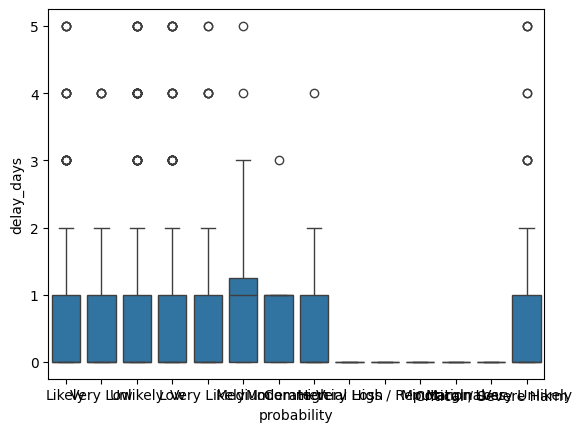

In [124]:
import seaborn as sns

sns.boxplot(x='probability', y='delay_days', data=data)
plt.show()

In [125]:
pd.crosstab(data['ship_type'], data['incident_category'])

incident_category,Catastrophic-Major-Extreme,Critical-Severe,Marginal-Moderate-Medium,Minor-Low-Slight,Others
ship_type,,,,,
BULK CARRIER,5,53,81,46,52
CONTAINER,10,69,96,62,27
LPG CARRIER,1,5,11,3,2
NAN,0,0,0,0,2
OIL TANKER,1,20,69,31,15
TANKER,13,78,138,90,60


In [126]:
data['desc_length'] = data['description'].apply(len)

data['desc_length'].describe()

count    1040.000000
mean      419.918269
std       370.559162
min        14.000000
25%       177.750000
50%       332.500000
75%       538.250000
max      3714.000000
Name: desc_length, dtype: float64

In [127]:
from collections import Counter

words = " ".join(data['description']).split()
Counter(words).most_common(20)

[('the', 4518),
 ('was', 2102),
 ('to', 2050),
 ('and', 1842),
 ('of', 1370),
 ('on', 939),
 ('in', 929),
 ('at', 560),
 ('that', 536),
 ('for', 477),
 ('from', 463),
 ('crew', 434),
 ('not', 425),
 ('THE', 410),
 ('a', 408),
 ('were', 395),
 ('it', 380),
 ('with', 378),
 ('found', 347),
 ('vessel', 330)]